In [6]:
import os
import sys
import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

SCRIPT_DIR = os.path.dirname(os.path.realpath(os.path.join(os.path.dirname(os.getcwd()))))
sys.path.append(SCRIPT_DIR)

import gwfast.gwfastGlobals as glob
import gwfast.waveforms as waveforms
import gwfast.signal as signal
import gwfast.network as network
import gwfast.fisherTools as fTools
import gwfast.gwfastUtils as utils

## Parameters, waveform, and detector setup

In [7]:
# Two events that are completely identical except in lensing parameters
events = {
    'Mc':np.array([30, 30]), 'eta':np.array([0.24, 0.24]), 'dL':np.array([2, 2]), 'theta':np.array([2.34, 2.34]), 'phi':np.array([5.43, 5.43]), 
    'iota':np.array([0.99*np.pi/2, 0.99*np.pi/2]), 'psi':np.array([1, 1]), 'tcoal':np.array([0, 0]), 'Phicoal':np.array([2.8, 2.8]), 
    'chi1z':np.array([1e-3, 1e-3]), 'chi2z':np.array([1e-3, 1e-3]), 'chi1x':np.array([0, 0]), 'chi2x':np.array([0, 0]), 'chi1y':np.array([0, 0]), 'chi2y':np.array([0, 0]), 
    'LambdaTilde':np.array([0, 0]), 'deltaLambda':np.array([0, 0]), 'ecc':np.array([0, 0]), 
    'R_orbit':np.array([200, 50]), 'M_lens':np.array([1e4, 1e5]), 'src_pos':np.array([0.7, 0.1])
}

# Using TaylorF2 for now to speed things up
mywf = waveforms.IMRPhenomD()

In [8]:
# Overview of lensing effects
utils.lens(events)

Image 1 parameters: {'Mc': Array([29.66473305, 29.65945376], dtype=float64), 'eta': array([0.24, 0.24]), 'dL': array([2, 2]), 'theta': array([2.34, 2.34]), 'phi': array([5.43, 5.43]), 'iota': Array([1.52741231, 1.35959424], dtype=float64), 'psi': Array([1.00150888, 1.00076661], dtype=float64), 'tcoal': array([0, 0]), 'Phicoal': Array([2.71414584, 2.75412508], dtype=float64), 'chi1z': array([0.001, 0.001]), 'chi2z': array([0.001, 0.001]), 'chi1x': array([0, 0]), 'chi2x': array([0, 0]), 'chi1y': array([0, 0]), 'chi2y': array([0, 0]), 'LambdaTilde': array([0, 0]), 'deltaLambda': array([0, 0]), 'ecc': array([0, 0]), 'R_orbit': array([200,  50]), 'M_lens': array([ 10000., 100000.]), 'src_pos': array([0.7, 0.1])} 
Image 2 parameters: {'Mc': Array([30.34146809, 30.34694608], dtype=float64), 'eta': array([0.24, 0.24]), 'dL': array([2, 2]), 'theta': array([2.34, 2.34]), 'phi': array([5.43, 5.43]), 'iota': Array([1.58275239, 1.74997432], dtype=float64), 'psi': Array([0.99848966, 0.99923301], dty

In [9]:
# Detector configurations
L1_conf = copy.deepcopy(glob.detectors).pop('L1')
L1_conf['psd_path'] = os.path.join(glob.detPath, 'observing_scenarios_paper', 'AplusDesign.txt')

H1_conf = copy.deepcopy(glob.detectors).pop('H1')
H1_conf['psd_path'] = os.path.join(glob.detPath, 'observing_scenarios_paper', 'AplusDesign.txt')

Virgo_conf = copy.deepcopy(glob.detectors).pop('Virgo')
Virgo_conf['psd_path'] =  os.path.join(glob.detPath, 'observing_scenarios_paper', 'avirgo_O5low_NEW.txt')

# Initialise the GWSignal objects
L1 = signal.GWSignal(mywf, psd_path=L1_conf['psd_path'], 
                        detector_shape=L1_conf['shape'], det_lat=L1_conf['lat'], 
                        det_long=L1_conf['long'], det_xax=L1_conf['xax'],
                        fmin=10
                        )
H1 = signal.GWSignal(mywf, psd_path=H1_conf['psd_path'], 
                        detector_shape=H1_conf['shape'], det_lat=H1_conf['lat'], 
                        det_long=H1_conf['long'], det_xax=H1_conf['xax'],
                        fmin=10
                        )
Virgo = signal.GWSignal(mywf, psd_path=Virgo_conf['psd_path'], 
                        detector_shape=Virgo_conf['shape'], det_lat=Virgo_conf['lat'], 
                        det_long=Virgo_conf['long'], det_xax=Virgo_conf['xax'],
                        fmin=10
                        )

mySignals = {'L1':L1, 'H1':H1, 'Virgo':Virgo}
myNet = network.DetNet(mySignals)

Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/AplusDesign.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8
Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/AplusDesign.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8
Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/avirgo_O5low_NEW.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8


## Strain

In [10]:
# Prepare frequency domain data
f_array = np.geomspace(10, 400, num=500)
ev = 0
event_1_strain = L1.GWstrain(f_array, events['Mc'][ev], events['eta'][ev], events['dL'][ev], events['theta'][ev], events['phi'][ev], events['iota'][ev], 
                       events['psi'][ev], events['tcoal'][ev], events['Phicoal'][ev], events['chi1z'][ev], events['chi2z'][ev], 
                       events['chi1x'][ev], events['chi2x'][ev], events['chi1y'][ev], events['chi2y'][ev], events['LambdaTilde'][ev], events['deltaLambda'][ev], events['ecc'][ev], 
                       R_orbit=events['R_orbit'][ev], M_lens=events['M_lens'][ev], src_pos=events['src_pos'][ev], use_lensing=True)
event_1_strain_unlensed = L1.GWstrain(f_array, events['Mc'][ev], events['eta'][ev], events['dL'][ev], events['theta'][ev], events['phi'][ev], events['iota'][ev], 
                       events['psi'][ev], events['tcoal'][ev], events['Phicoal'][ev], events['chi1z'][ev], events['chi2z'][ev], 
                       events['chi1x'][ev], events['chi2x'][ev], events['chi1y'][ev], events['chi2y'][ev], events['LambdaTilde'][ev], events['deltaLambda'][ev], events['ecc'][ev], 
                       R_orbit=events['R_orbit'][ev], M_lens=events['M_lens'][ev], src_pos=events['src_pos'][ev], use_lensing=False)

In [20]:
# Prepare time domain data
sampling_frequency = 1000
f_array_lin = np.linspace(10, 400, sampling_frequency)
duration = 1 / (f_array_lin[1] - f_array_lin[0])
t_array = np.linspace(-duration, 0, sampling_frequency, endpoint=False)

ev = 0
event_1_strain_lin = L1.GWstrain(f_array_lin, events['Mc'][ev], events['eta'][ev], events['dL'][ev], events['theta'][ev], events['phi'][ev], events['iota'][ev], 
                       events['psi'][ev], events['tcoal'][ev], events['Phicoal'][ev], events['chi1z'][ev], events['chi2z'][ev], 
                       events['chi1x'][ev], events['chi2x'][ev], events['chi1y'][ev], events['chi2y'][ev], events['LambdaTilde'][ev], events['deltaLambda'][ev], events['ecc'][ev], 
                       R_orbit=events['R_orbit'][ev], M_lens=events['M_lens'][ev], src_pos=events['src_pos'][ev], use_lensing=True)
event_1_strain_unlensed_lin = L1.GWstrain(f_array_lin, events['Mc'][ev], events['eta'][ev], events['dL'][ev], events['theta'][ev], events['phi'][ev], events['iota'][ev], 
                       events['psi'][ev], events['tcoal'][ev], events['Phicoal'][ev], events['chi1z'][ev], events['chi2z'][ev], 
                       events['chi1x'][ev], events['chi2x'][ev], events['chi1y'][ev], events['chi2y'][ev], events['LambdaTilde'][ev], events['deltaLambda'][ev], events['ecc'][ev], 
                       R_orbit=events['R_orbit'][ev], M_lens=events['M_lens'][ev], src_pos=events['src_pos'][ev], use_lensing=False)

event_1_strain_t = np.fft.ifft(event_1_strain_lin)
event_1_strain_unlensed_t = np.fft.ifft(event_1_strain_unlensed_lin)

# Wrap ringdown to the end
post_merger_time = -0.02
n_index = int(post_merger_time * sampling_frequency)
event_1_strain_t_shifted = np.roll(event_1_strain_t, n_index)
event_1_strain_unlensed_t_shifted = np.roll(event_1_strain_unlensed_t, n_index)

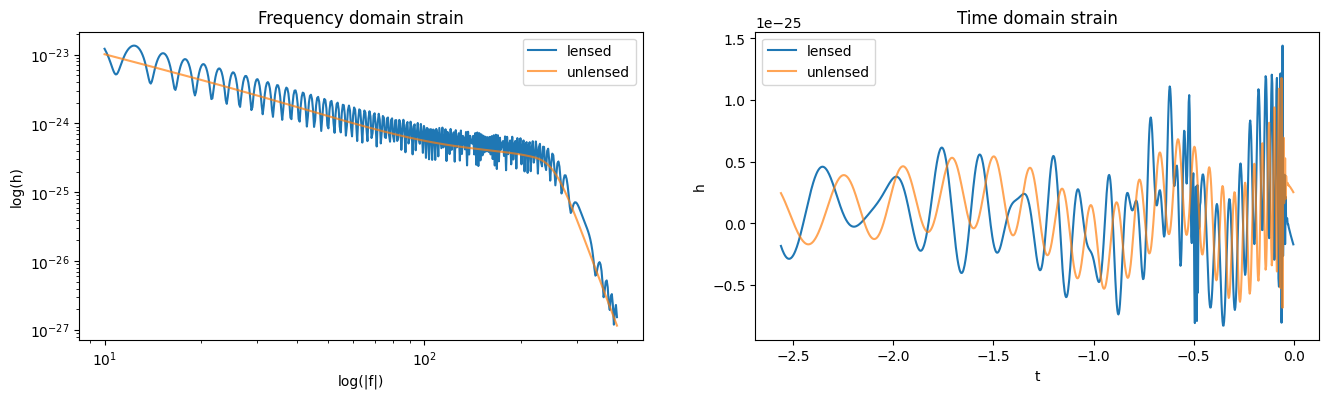

In [21]:
fig, axs = plt.subplots(1, 2, figsize=(16,4))

axs[0].loglog(f_array, np.abs(event_1_strain), label='lensed')
axs[0].loglog(f_array, np.abs(event_1_strain_unlensed), alpha=0.7, label='unlensed')
axs[0].set_title('Frequency domain strain')
axs[0].set_xlabel('log(|f|)')
axs[0].set_ylabel('log(h)')
axs[0].legend()

axs[1].plot(t_array, event_1_strain_t_shifted.real, label='lensed')
axs[1].plot(t_array, event_1_strain_unlensed_t_shifted.real, alpha=0.7, label='unlensed')
axs[1].set_title('Time domain strain')
axs[1].set_xlabel('t')
axs[1].set_ylabel('h')
axs[1].legend()

## SNR

In [22]:
mySNR = myNet.SNR(events, use_lensing=True, return_all=True)
mySNR_nolens = myNet.SNR(events, return_all=True)
print("SNR with lensing:", mySNR)
print("SNR without lensing:", mySNR_nolens)

SNR with lensing: {'L1': Array([16.54615494, 17.14728335], dtype=float64), 'H1': Array([15.61368245, 16.42274751], dtype=float64), 'Virgo': Array([6.3536478 , 6.65895401], dtype=float64), 'net': array([23.62056653, 24.65923013])}
SNR without lensing: {'L1': Array([8.52162476, 8.52162476], dtype=float64), 'H1': Array([8.02228693, 8.02228693], dtype=float64), 'Virgo': Array([3.21066458, 3.21066458], dtype=float64), 'net': array([12.13604314, 12.13604314])}


## Fisher

In [23]:
# Fisher matrix (3-detector network) with lensing
FisherMatrsNet = myNet.FisherMatr(events, use_lensing=True)
# Group internal and external parameters together
order = [0, 1, 7, 8, 9, 10, 11, 12, 13, 2, 3, 4, 5, 6]
FisherMatrsNet = FisherMatrsNet[np.ix_(order, order)]
param_labels = (r'${\cal M}$', r'$\eta$', r'$t_{\rm c}$', r'$\phi_{\rm c}$',
    r'$\chi_{S}$', r'$\chi_{A}$', r'$R_{\rm orb}$', r'$M_{\rm L}$', r'$y$',
    r'$D_{\rm L}$', r'$\alpha$', r'$\delta$', r'$\iota$', r'$\psi$'
)

Computing Fisher for L1...
Computing derivatives...


Computing Fisher for H1...
Computing derivatives...
Computing Fisher for Virgo...
Computing derivatives...
Done.


Text(0.5, 1.0, 'Rescaled Fisher matrix (event 1 with lensing)')

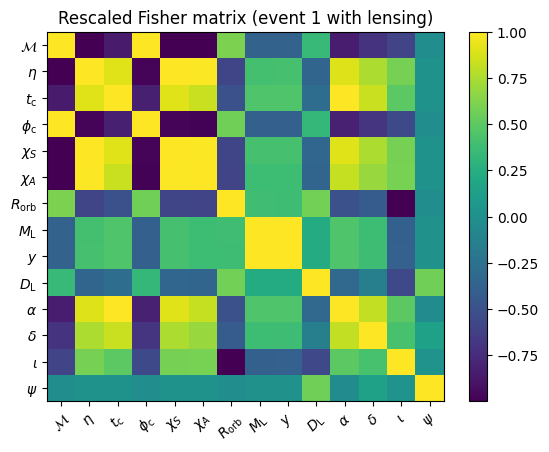

In [24]:
# Plot Fisher matrix
matrix = FisherMatrsNet[:, :, 0]
sqrt_diagonal = np.sqrt(np.diag(matrix))
sqrt_diagonal_inv = np.diag(1 / sqrt_diagonal)
matrix_rescaled = sqrt_diagonal_inv @ matrix @ sqrt_diagonal_inv

fig, ax = plt.subplots()
x = np.arange(0, matrix_rescaled.shape[0]+1, 1)
y = np.arange(matrix_rescaled.shape[1], -1, -1)
im = ax.pcolormesh(x, y, matrix_rescaled)
fig.colorbar(im)
ax.set_xticks(np.arange(0, matrix_rescaled.shape[0], 1)+0.5, param_labels, rotation=45)
ax.set_yticks(np.arange(matrix_rescaled.shape[1], 0, -1)-0.5, param_labels)
ax.set_title('Rescaled Fisher matrix (event 1 with lensing)')

In [25]:
# Get covariance matrix and inversion error
Cov, ie = fTools.CovMatr(FisherMatrsNet)

var_event_1 = np.diag(Cov[:,:,0])
params = ['Mc', 'eta', 'tcoal', 'Phicoal', 'chiS', 'chiA', 'R_orbit', 'M_lens', 'src_pos', 'dL', 'alpha', 'delta', 'iota', 'psi']
print("Variances for event 1 with lensing:", ['{}: {:.6f}'.format(params[i], var_event_1[i]) for i in range(len(params))])
print("Inversion error with lensing:", ie)

Variances for event 1 with lensing: ['Mc: 0.223822', 'eta: 0.001819', 'tcoal: 0.001292', 'Phicoal: 10.577062', 'chiS: 9.192324', 'chiA: 21.777974', 'R_orbit: 72643.269429', 'M_lens: 8599178.136546', 'src_pos: 0.039056', 'dL: 0.121459', 'alpha: 0.004987', 'delta: 0.000296', 'iota: 0.064568', 'psi: 0.011794']
Inversion error with lensing: [2.75595355e-07 3.05499882e-03]


In [26]:
# Calculate fractional uncertainty
# For angular parameters, this is calculated as std / length of interval of possible values (2pi for Phicoal, alpha and psi, pi for delta and iota)
# For normalized parameters, this is taken as std (eta, src_pos)
# For all other parameters, this is calculated as std / injected value

ev = 0
chiS = 0.5 * (events['chi1z'][ev] + events['chi2z'][ev])
chiA = 0.5 * (events['chi1z'][ev] - events['chi2z'][ev])
scale_factor = [events['Mc'][ev], 1, events['tcoal'][ev], 2*np.pi, chiS, chiA, 
                events['R_orbit'][ev], events['M_lens'][ev], 1, 
                events['dL'][ev], 2*np.pi, np.pi, np.pi, 2*np.pi]
fractional_uncertainty = np.sqrt(var_event_1) / scale_factor
fractional_uncertainty

/var/folders/b4/hg5l8r9915b4cr385qb8sfdw0000gn/T/ipykernel_28724/3171910240.py:12: RuntimeWarning: divide by zero encountered in divide
  fractional_uncertainty = np.sqrt(var_event_1) / scale_factor


array([1.57699521e-02, 4.26465019e-02,            inf, 5.17610008e-01,
       3.03188449e+03,            inf, 1.34762077e+00, 2.93243553e-01,
       1.97624827e-01, 1.74254793e-01, 1.12390245e-02, 5.48010212e-03,
       8.08835241e-02, 1.72845110e-02], dtype=float128)

Text(0.5, 1.0, 'Correlation matrix (event 1 with lensing)')

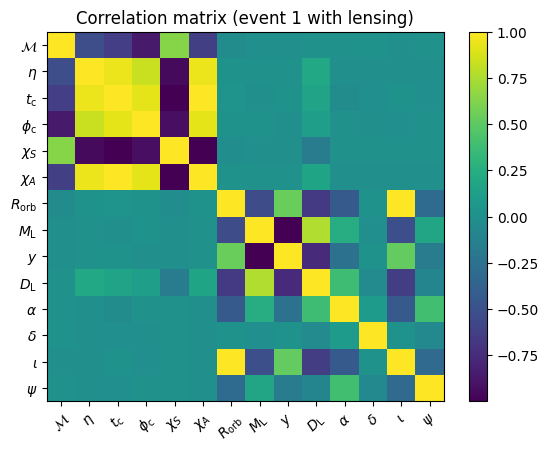

In [27]:
# Plot correlation coefficients
matrix = Cov[:, :, 0]
sqrt_diagonal = np.sqrt(np.diag(matrix))
sqrt_diagonal_inv = np.diag(1 / sqrt_diagonal)
matrix_rescaled = sqrt_diagonal_inv @ matrix @ sqrt_diagonal_inv

param_labels = (r'${\cal M}$', r'$\eta$', r'$t_{\rm c}$', r'$\phi_{\rm c}$',
    r'$\chi_{S}$', r'$\chi_{A}$', r'$R_{\rm orb}$', r'$M_{\rm L}$', r'$y$',
    r'$D_{\rm L}$', r'$\alpha$', r'$\delta$', r'$\iota$', r'$\psi$'
)
fig, ax = plt.subplots()
x = np.arange(0, matrix_rescaled.shape[0]+1, 1)
y = np.arange(matrix_rescaled.shape[1], -1, -1)
im = ax.pcolormesh(x, y, matrix_rescaled)
fig.colorbar(im)
ax.set_xticks(np.arange(0, matrix_rescaled.shape[0], 1)+0.5, param_labels, rotation=45)
ax.set_yticks(np.arange(matrix_rescaled.shape[1], 0, -1)-0.5, param_labels)
ax.set_title('Correlation matrix (event 1 with lensing)')

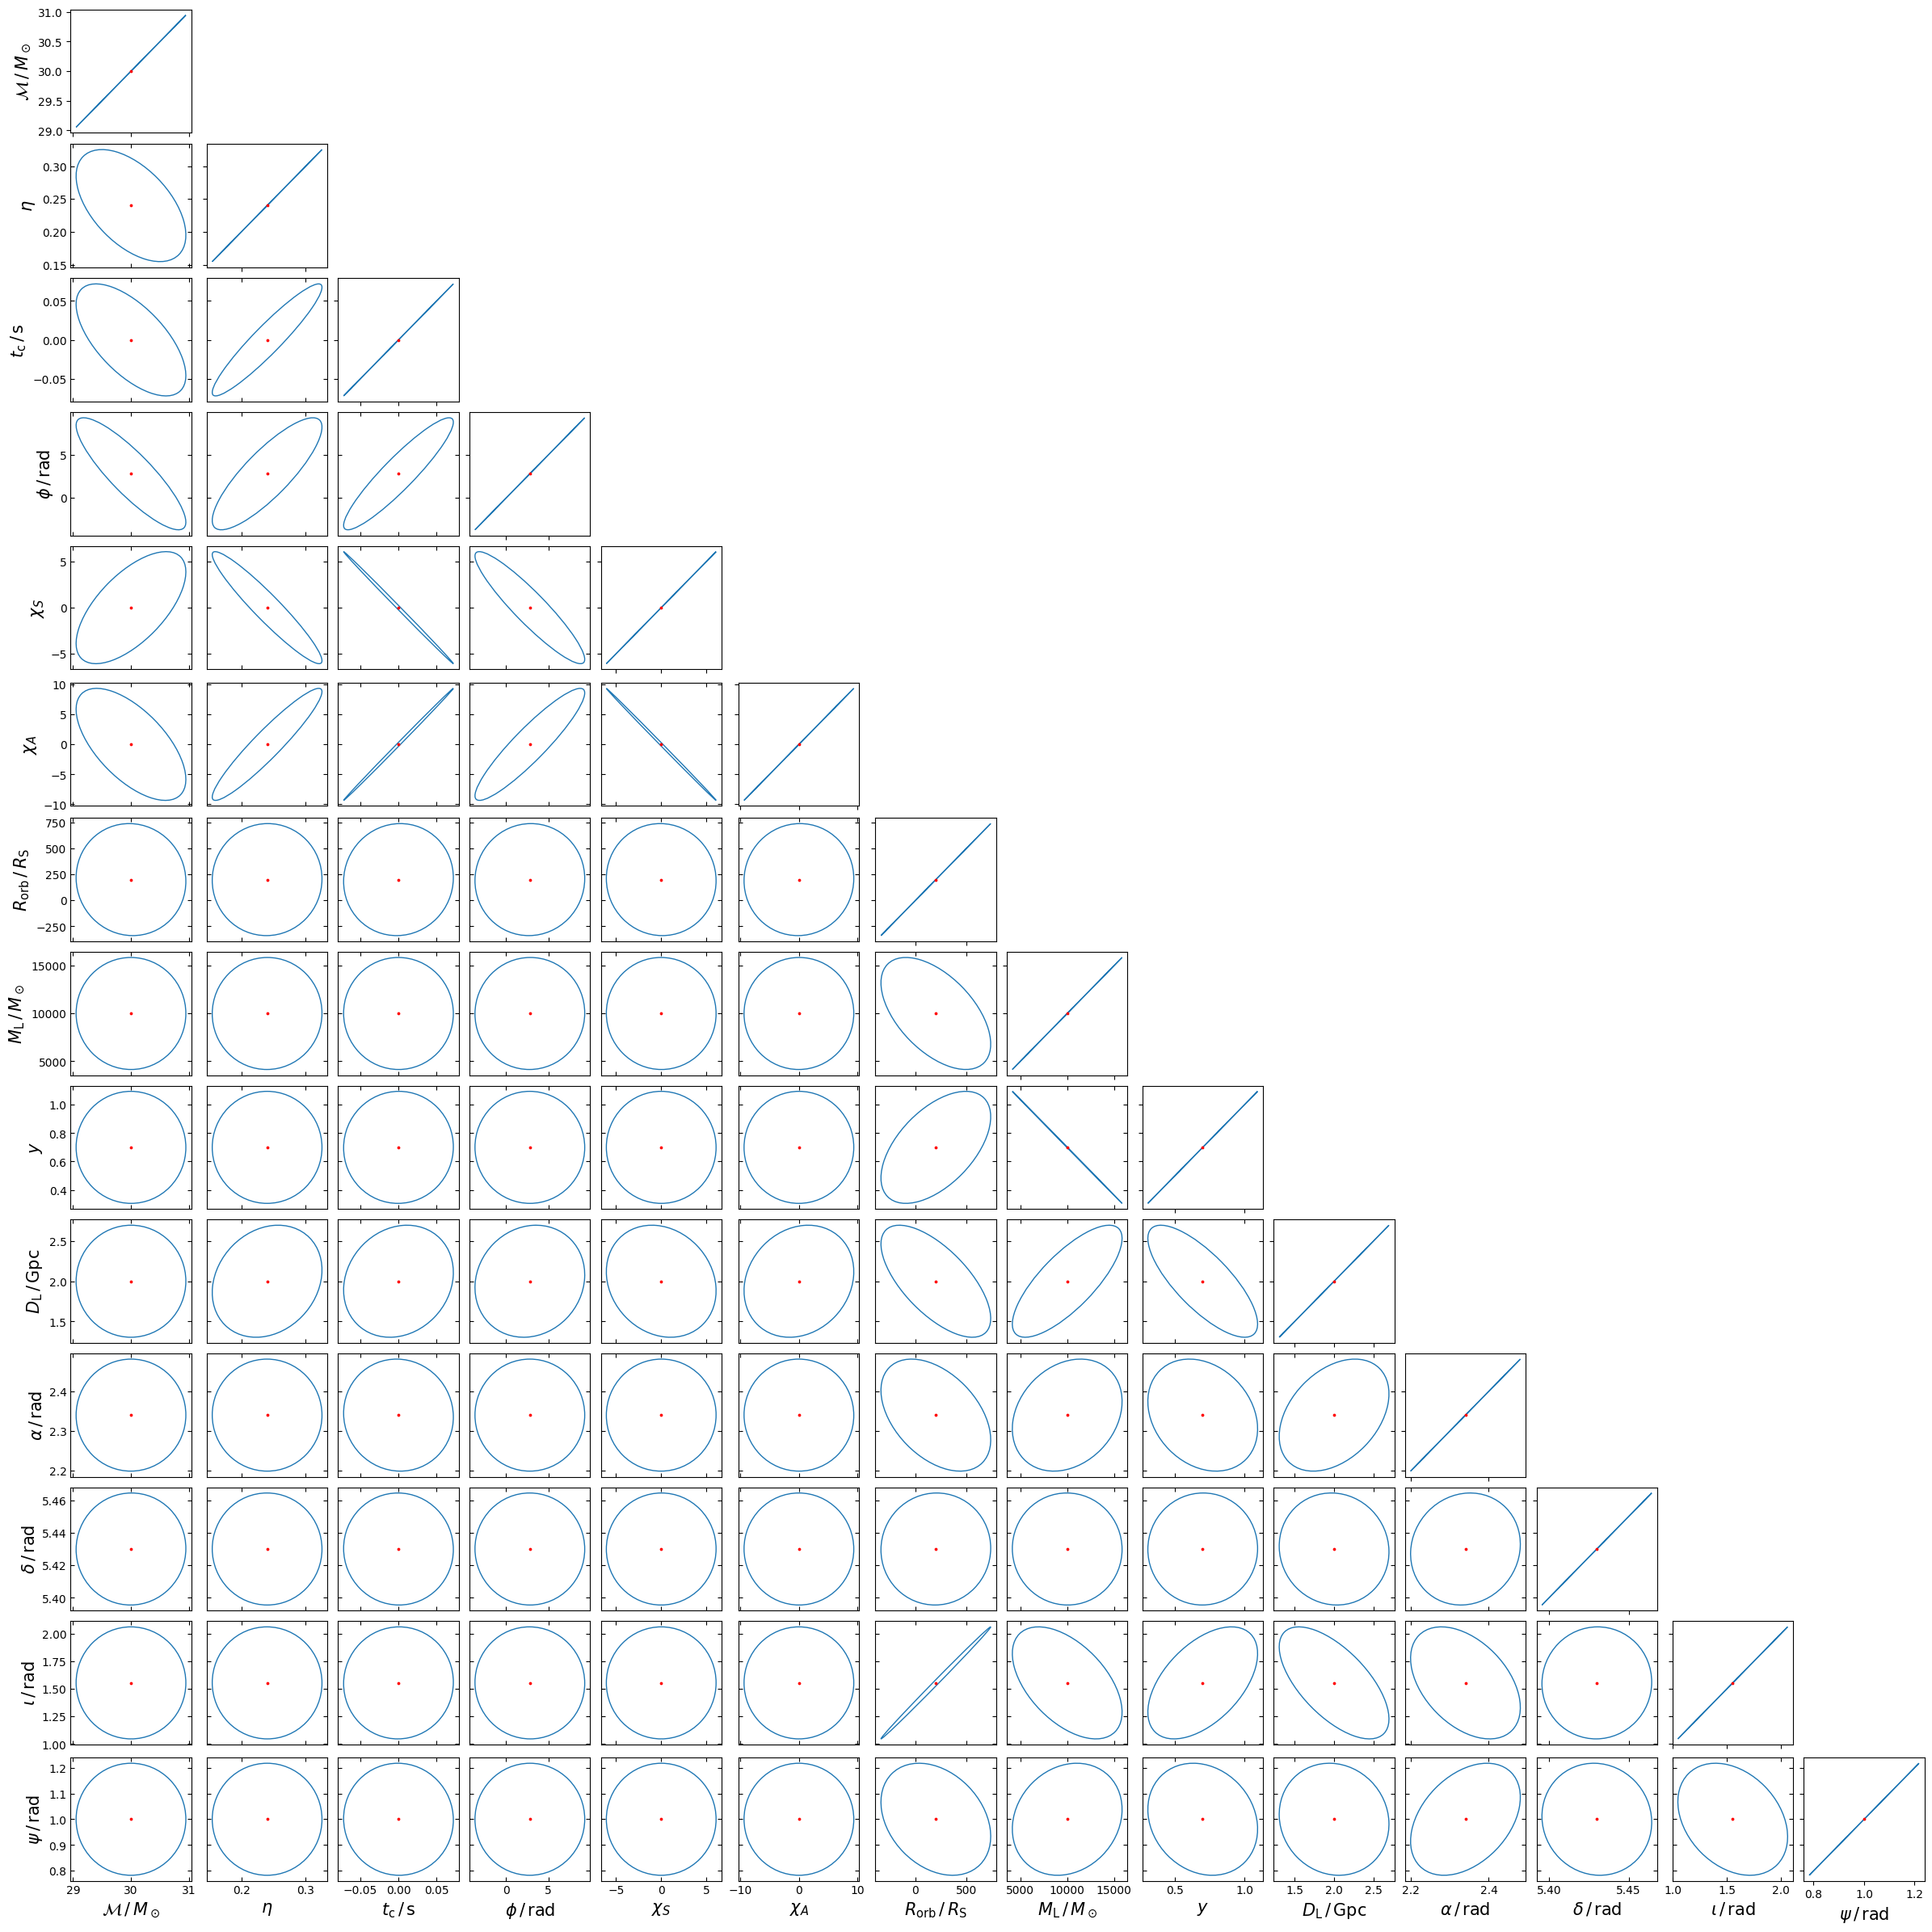

In [28]:
params = ('Mc', 'eta', 'tcoal', 'Phicoal', 'chiS', 'chiA', 'R_orbit', 'M_lens', 'src_pos', 'dL', 'theta', 'phi', 'iota', 'psi')
# We rearranged the list of parameters, so the indices needs to be updated accordingly
indices = np.arange(0, 14)

labels = {
    'Mc': r'${\cal M}\,/\,M_\odot$',
    'eta': r'$\eta$',
    'dL': r'$D_{\rm L}\,/\,{\rm Gpc}$',
    'theta': r'$\alpha\,/\,{\rm rad}$',
    'phi': r'$\delta\,/\,{\rm rad}$',
    'iota': r'$\iota\,/\,{\rm rad}$',
    'psi': r'$\psi\,/\,{\rm rad}$',
    'tcoal': r'$t_{\rm c}\,/\,{\rm s}$',
    'Phicoal': r'$\phi\,/\,{\rm rad}$',
    'chiS': r'$\chi_{S}$',
    'chiA': r'$\chi_{A}$',
    'R_orbit': r'$R_{\rm orb}\,/\,R_{\rm S}$',
    'M_lens': r'$M_{\rm L}\,/\,M_\odot$',
    'src_pos': r'$y$'
}

events['chiS'] = 0.5 * (events['chi1z'] + events['chi2z'])
events['chiA'] = 0.5 * (events['chi1z'] - events['chi2z'])
event = {key: val[0] for key, val in events.items()}

fig = fTools.plot_corners(
    Cov[:, :, 0], params, indices, 
    event=event, labels=labels, color='C0'
)

fig.savefig('test_Fisher_matrix.png', dpi=200)